# MNIST Classifier - MLP, CNN

In [1]:
import kagglehub
from torch.nn import CrossEntropyLoss

# Download latest version
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Path to dataset files:", path)

/home/skandan-c-y/PycharmProjects/PyTorch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/skandan-c-y/.cache/kagglehub/datasets/oddrationale/mnist-in-csv/versions/2


In [2]:
import numpy as np
import pandas as pd

In [3]:
test_data = pd.read_csv(path + "/mnist_test.csv")
train_data = pd.read_csv(path + "/mnist_train.csv")

In [4]:
print(train_data[:5])
print(test_data[:5])

   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      7    0    0    0    0    0    0    0    0    0  ...      0      0   
1      

In [5]:
# reshaping the data

from sklearn.model_selection import train_test_split

train = train_data.drop(columns=['label'])
train = train / 255.0
test = test_data.drop(columns=['label'])
test = test / 255.0

train_labels = train_data['label']
test_labels = test_data['label']

train, val, train_labels, val_labels = train_test_split(train, train_labels, test_size=0.2, shuffle=True)

## PyTorch

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [7]:
x_train = torch.tensor(data=train.values, dtype=torch.float32)
y_train = torch.tensor(data=train_labels.values, dtype=torch.long)

x_test = torch.tensor(data=test.values, dtype=torch.float32)
y_test = torch.tensor(data=test_labels.values, dtype=torch.long)

x_val = torch.tensor(data=val.values, dtype=torch.float32)
y_val = torch.tensor(data=val_labels.values, dtype=torch.long)

In [8]:
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)
val_dataset = TensorDataset(x_val, y_val)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True, num_workers=3)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=True, num_workers=3)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=True, num_workers=3)

## Defining an MLP Model

In [9]:
class mlp_model(nn.Module):
    def __init__(self):
        super(mlp_model, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 48),
            nn.ReLU(),
            nn.Linear(48,10)
        )

    def forward(self, x):
        return self.network(x)

In [10]:
model = mlp_model().to('cuda')
criterion = nn.CrossEntropyLoss()

import torch.optim as optim
optm = optim.Adam(lr=1e-3, params=model.parameters())

### Training and Validation loop

In [11]:
print("##### Training with Validation #####")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
best_val_loss = float('inf')
epochs = 5

training_losses = []
validation_losses = []

for e in range(epochs):

    # training loop
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_batch_pred = model(x_batch)
        loss = criterion(y_batch_pred, y_batch)

        optm.zero_grad()
        loss.backward()
        optm.step()

        train_loss += loss.item() * x_batch.size(0)

        preds = y_batch_pred.argmax(dim=1)
        train_correct += (y_batch == preds).sum().item()
        train_total += y_batch.size(0)

    train_loss /= train_total
    training_losses.append(train_loss)
    train_acc = train_correct / train_total


    # validation loop
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_batch_pred = model(x_batch)
            loss = criterion(y_batch_pred, y_batch)

            val_loss += loss.item() * x_batch.size(0)

            preds = y_batch_pred.argmax(dim=1)
            val_correct += (y_batch == preds).sum().item()
            val_total += y_batch.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total
        validation_losses.append(val_loss)

    print(f"{e+1}/{epochs} \t|| training loss: {train_loss:.5f} \t|| training accuracy: {train_acc:.5f} \t|| validation loss: {val_loss:.5f} \t|| validation accuracy: {val_acc:.5f} ")

##### Training with Validation #####
1/5 	|| training loss: 0.35471 	|| training accuracy: 0.89419 	|| validation loss: 0.16711 	|| validation accuracy: 0.95033 
2/5 	|| training loss: 0.13397 	|| training accuracy: 0.96013 	|| validation loss: 0.11778 	|| validation accuracy: 0.96308 
3/5 	|| training loss: 0.08723 	|| training accuracy: 0.97344 	|| validation loss: 0.10615 	|| validation accuracy: 0.96642 
4/5 	|| training loss: 0.06512 	|| training accuracy: 0.97950 	|| validation loss: 0.09501 	|| validation accuracy: 0.97042 
5/5 	|| training loss: 0.05068 	|| training accuracy: 0.98369 	|| validation loss: 0.09261 	|| validation accuracy: 0.97175 


## Visualizing the Losses

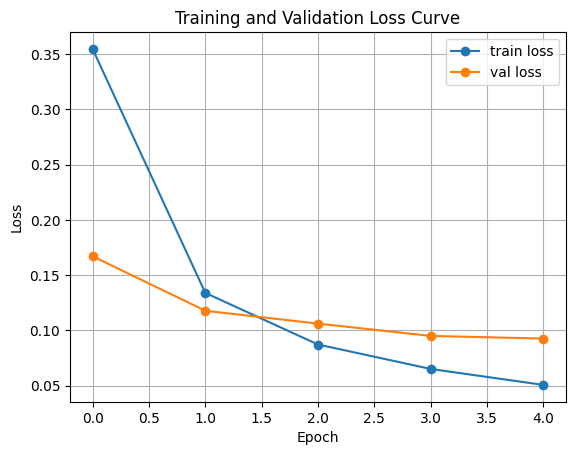

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(range(epochs),training_losses, marker='o', label='train loss')
plt.plot(range(epochs), validation_losses, marker='o', label='val loss')

plt.title("Training and Validation Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

## Defining a CNN model

In [13]:
x_train = x_train.view(-1, 1, 28, 28)
x_val   = x_val.view(-1, 1, 28, 28)
x_test  = x_test.view(-1, 1, 28, 28)

In [14]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(x_train, y_train)
val_dataset   = TensorDataset(x_val, y_val)
test_dataset  = TensorDataset(x_test, y_test)

In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [16]:
for x, y in train_loader:
    print(x.shape)  # must be (B, 1, 28, 28)
    print(y.shape)  # must be (B,)
    break

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [17]:
class cnn_model(nn.Module):
    def __init__(self):
        super(cnn_model, self).__init__()

        # feature extractor
        self.cnn_nw = nn.Sequential(
            nn.Conv2d(in_channels=1,                # shape: ip:28, op:floor(28+2*0-3/1)+1=26
                      out_channels=32,
                      kernel_size=(3,3),
                      stride=(1,1)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),         # shape: ip:13, op:((26-2*1+2)/2)+1=13
                         stride=(2,2),
                         padding=1),

            nn.Conv2d(in_channels=32,               # shape: ip:13, op:floor((13-3)/1)+1=11
                      out_channels=64,
                      kernel_size=(3,3),
                      stride=(1,1)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2),         # shape: ip:11, op:((11-2)/2)+1=6
                         stride=(2,2))
        )

        # network
        self.clf = nn.Sequential(
            nn.Flatten(),                           # shape: 64*6*6 = 2304
            nn.Linear(in_features=64*6*6, out_features=128),
            nn.Dropout(0.3),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=32),
            nn.ReLU(),
            nn.Linear(in_features=32, out_features=10)
        )

    def forward(self, x):
        x = self.cnn_nw(x)
        x = self.clf(x)
        return x

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

cnn = cnn_model().to(device)
cnn_loss = nn.CrossEntropyLoss()

from torch.optim import Adam
cnn_optm = Adam(lr=0.001, params=cnn.parameters())

In [19]:
cnn_epochs = 5
cnn_training_loss = []
cnn_validation_loss = []
best_val_loss = float('inf')

for e in range(cnn_epochs):
    cnn.train()
    epoch_training_loss = 0.0
    epoch_training_total = 0
    epoch_training_correct = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        y_batch_preds = cnn(x_batch)
        batch_loss = cnn_loss(y_batch_preds, y_batch)

        cnn_optm.zero_grad()
        batch_loss.backward()
        cnn_optm.step()

        epoch_training_loss += batch_loss.item() * x_batch.size(0)

        preds = y_batch_preds.argmax(dim=1)
        epoch_training_correct += (y_batch == preds).sum().item()
        epoch_training_total += y_batch.size(0)

    epoch_training_loss /= epoch_training_total
    cnn_training_loss.append(epoch_training_loss)
    epoch_training_acc = epoch_training_correct / epoch_training_total


    # validation loop
    cnn.eval()
    epoch_val_loss = 0.0
    epoch_val_correct = 0
    epoch_val_total = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_batch_pred = cnn(x_batch)
            loss = cnn_loss(y_batch_pred, y_batch)

            epoch_val_loss += loss.item() * x_batch.size(0)

            preds = y_batch_pred.argmax(dim=1)
            epoch_val_correct += (y_batch == preds).sum().item()
            epoch_val_total += y_batch.size(0)

    epoch_val_loss /= len(val_loader.dataset)
    epoch_val_acc = epoch_val_correct / epoch_val_total
    cnn_validation_loss.append(epoch_val_loss)

    print(f"{e+1}/{cnn_epochs} \t|| training loss: {epoch_training_loss:.5f} \t|| training accuracy: {epoch_training_acc:.5f} \t|| validation loss: {epoch_val_loss:.5f} \t|| validation accuracy: {epoch_val_acc:.5f} ")

1/5 	|| training loss: 0.32730 	|| training accuracy: 0.89517 	|| validation loss: 0.08516 	|| validation accuracy: 0.97242 
2/5 	|| training loss: 0.09707 	|| training accuracy: 0.97102 	|| validation loss: 0.06367 	|| validation accuracy: 0.97917 
3/5 	|| training loss: 0.06930 	|| training accuracy: 0.97956 	|| validation loss: 0.05177 	|| validation accuracy: 0.98408 
4/5 	|| training loss: 0.05750 	|| training accuracy: 0.98240 	|| validation loss: 0.04009 	|| validation accuracy: 0.98742 
5/5 	|| training loss: 0.04498 	|| training accuracy: 0.98617 	|| validation loss: 0.04104 	|| validation accuracy: 0.98775 


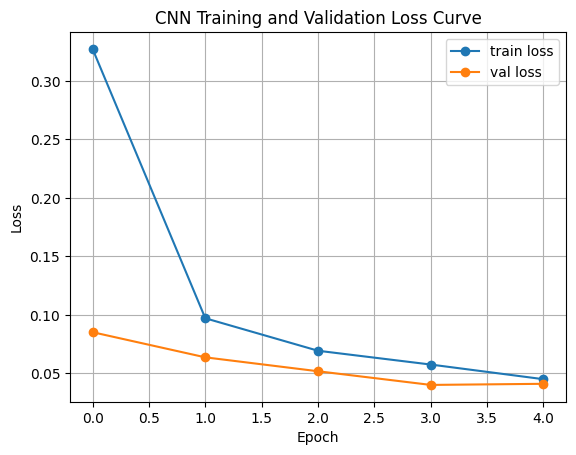

In [20]:
plt.plot(range(cnn_epochs), cnn_training_loss, marker='o', label='train loss')
plt.plot(range(cnn_epochs), cnn_validation_loss, marker='o', label='val loss')

plt.title("CNN Training and Validation Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

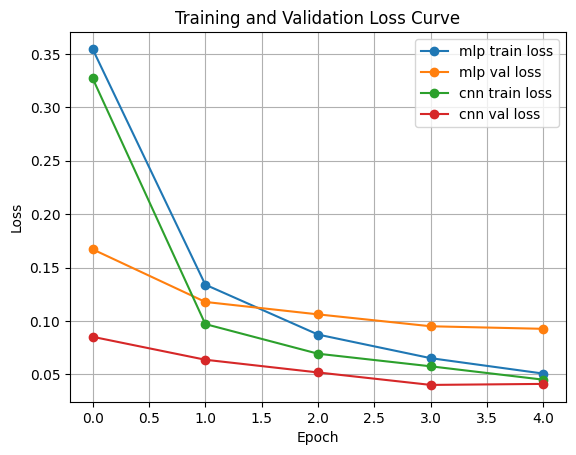

In [21]:
plt.plot(range(epochs),training_losses, marker='o', label='mlp train loss')
plt.plot(range(epochs), validation_losses, marker='o', label='mlp val loss')
plt.plot(range(cnn_epochs), cnn_training_loss, marker='o', label='cnn train loss')
plt.plot(range(cnn_epochs), cnn_validation_loss, marker='o', label='cnn val loss')

plt.title("Training and Validation Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()


In [22]:
print(f"mlp training loss: {training_losses}\nmlp validation loss: {validation_losses}, cnn training loss: {cnn_training_loss}, cnn validation loss: {cnn_validation_loss}")

mlp training loss: [0.3547051906088988, 0.1339658946270744, 0.08723104143018524, 0.06512380183177689, 0.05067590061932181]
mlp validation loss: [0.16711085838079454, 0.11778208169837792, 0.10614859442288677, 0.09500668950378895, 0.0926090120561421], cnn training loss: [0.3272990194434921, 0.09706785247661173, 0.06929753675684333, 0.05750080030690879, 0.04497594331810251], cnn validation loss: [0.08516318534066279, 0.06366502119600773, 0.05176729668801029, 0.040086758868768814, 0.04104126782870541]


## Observation

After multiple iterations, we observe the following details:
* MLP and CNN almost always have a similar training loss. But CNN always has a lesser validation loss and better validation loss
* CNN overfits without the `.Droupout(0.3)` as observed in the previous iterations.

In [23]:
torch.save(cnn.state_dict(), "mnist_cnn.pth")